In [7]:
import os
from pathlib import Path
import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [8]:
DATA_DIR = Path("../data")  # Change if needed

IMAGE_DIR = DATA_DIR / "images"
ANNOTATION_DIR = DATA_DIR / "annotations"

In [9]:
image_files = sorted(IMAGE_DIR.glob("*.png"))
xml_files = sorted(ANNOTATION_DIR.glob("*.xml"))

print(f"Number of images: {len(image_files)}")
print(f"Number of annotations: {len(xml_files)}")

Number of images: 853
Number of annotations: 853


In [10]:
class_counter = Counter()

for xml_file in xml_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        label = obj.find("name").text
        class_counter[label] += 1

print("Class distribution:")
for label, count in class_counter.items():
    print(f"{label}: {count}")

Class distribution:
without_mask: 717
with_mask: 3232
mask_weared_incorrect: 123


In [11]:
widths = []
heights = []

for image_path in image_files:
    with Image.open(image_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Average width : {sum(widths)/len(widths):.1f}")
print(f"Average height: {sum(heights)/len(heights):.1f}")

print(f"Min size: {min(widths)} x {min(heights)}")
print(f"Max size: {max(widths)} x {max(heights)}")

Average width : 370.6
Average height: 309.3
Min size: 193 x 156
Max size: 600 x 600


In [12]:
num_faces = []

for xml_file in xml_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    faces = len(root.findall("object"))
    num_faces.append(faces)

print(f"Average faces/image: {sum(num_faces)/len(num_faces):.2f}")
print(f"Maximum faces in one image: {max(num_faces)}")

Average faces/image: 4.77
Maximum faces in one image: 115


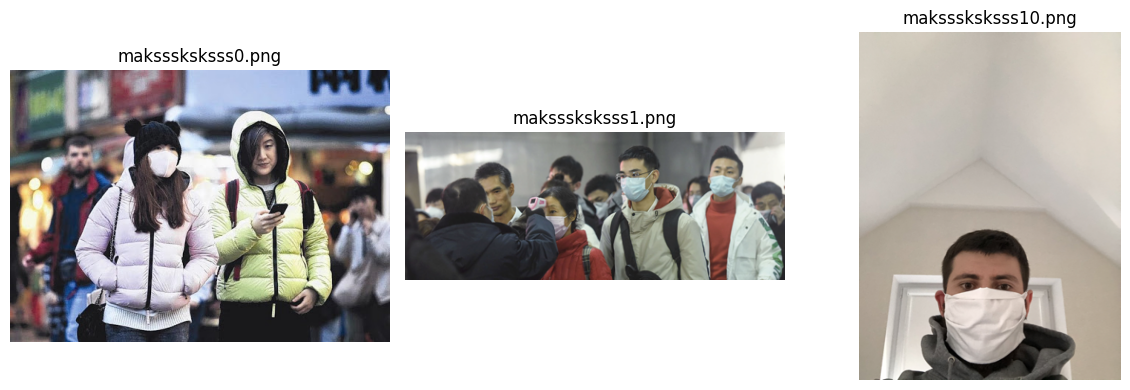

In [13]:
plt.figure(figsize=(12, 4))

for i in range(3):
    img = cv2.imread(str(image_files[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_files[i].name)

plt.tight_layout()
plt.show()